# 10. Modelado Predictivo de Demanda — Iteración 6: Descuentos Promocionales y Regiones Geográficas

## ¿De dónde venimos?

| Iteración | Novedad | MAE | R² |
|---|---|---|---|
| It4 — Log1p | Transformación logarítmica | 0.649 | 0.287 |
| It5 — Optuna + Target Enc | Hiperparámetros + memoria histórica SKU/municipio | 0.641 | 0.288 |
| **It6 — Esta iteración** | Descuentos promocionales + Regiones geográficas | **?** | **?** |

En la Iteración 5 concluimos que el modelo había llegado a un **techo con los datos disponibles**. La única forma de dar un salto real era incorporar información de negocio nueva. Esta iteración lo hace con dos mejoras:

## Dos mejoras nuevas

### Mejora 1 — Descuentos Promocionales (`por_descuento2`)
Validado en el notebook anterior: cuando hay un descuento promocional, la demanda se multiplica por **4.2x** de media. La correlación con unidades es **0.197**, la más alta de todo el proyecto. El dataset `df_final_modelado_it6.csv` ya incluye estas dos columnas nuevas:
- `hubo_descuento_promo`: ¿hubo promoción esa semana para ese SKU/municipio? (0/1)
- `valor_descuento_promo`: ¿cuánto fue el descuento? (0 si no hubo)

### Mejora 2 — Regiones Geográficas
España tiene 52 provincias con climas y comportamientos de compra muy distintos. Agruparlas en **6 regiones** permite al modelo:
- Capturar patrones climáticos macro (norte atlántico vs sur mediterráneo)
- Mejorar la predicción en provincias con poco histórico (Soria, Teruel, Zamora...) usando el patrón regional
- Crear interacciones región × clima más estables que provincia × clima

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')

print('Librerías cargadas.')

Librerías cargadas.


---
## 1. Carga del Dataset Enriquecido

Cargamos `df_final_modelado_it6.csv`, que ya incluye las dos variables de descuento generadas en el notebook anterior.

In [2]:
df = pd.read_csv('../Datasets/df_final_modelado_it6.csv', sep=';')

print(f'Dataset cargado. Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'\nVariables de descuento ya incluidas:')
print(f'  hubo_descuento_promo  — valores únicos: {sorted(df["hubo_descuento_promo"].unique())}')
print(f'  valor_descuento_promo — valores únicos: {sorted(df["valor_descuento_promo"].unique())}')
print(f'  Filas con promo: {df["hubo_descuento_promo"].sum():,} ({df["hubo_descuento_promo"].mean()*100:.2f}%)')

Dataset cargado. Shape: (252836, 21)
Columnas: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'importe_neto', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_semana', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max', 'valor_descuento_promo', 'hubo_descuento_promo']

Variables de descuento ya incluidas:
  hubo_descuento_promo  — valores únicos: [np.int64(0), np.int64(1)]
  valor_descuento_promo — valores únicos: [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(8.0), np.float64(10.0), np.float64(15.0)]
  Filas con promo: 3,783 (1.50%)


---
## 2. Nueva Feature: Regiones Geográficas

### ¿Por qué agrupar por regiones?

El modelo ya tiene `Provincia` como variable categórica. Sin embargo, hay un problema: **algunas provincias tienen muy pocas observaciones** (Soria, Teruel, Ávila, Zamora...). Con tan pocos datos, el modelo no puede aprender bien el comportamiento específico de esa provincia y tiende a generalizar mal.

La solución es añadir una variable de **región geográfica** que agrupe provincias con clima y comportamiento de compra similar. Así, aunque Soria tenga pocas observaciones, el modelo puede usar el patrón de toda la región Centro para inferir su comportamiento.

### Las 6 regiones de España

| Región | Provincias | Clima característico |
|---|---|---|
| **Noroeste** | Galicia, Asturias, Cantabria | Atlántico — lluvioso, temperaturas suaves todo el año |
| **Norte** | País Vasco, Navarra, La Rioja, Aragón | Transición atlántico-continental |
| **Noreste** | Cataluña, Valencia, Baleares | Mediterráneo — veranos secos y calurosos |
| **Centro** | Madrid, Castilla y León, Castilla-La Mancha, Extremadura | Continental — inviernos fríos, veranos muy secos |
| **Sur** | Andalucía, Murcia, Ceuta, Melilla | Mediterráneo-árido — la región más cálida |
| **Canarias** | Las Palmas, Tenerife | Subtropical — demanda estable todo el año |

In [3]:
# Diccionario de asignación provincia → región
REGION_MAP = {
    # Noroeste — clima atlántico
    'A CORUÑA':    'Noroeste',
    'LUGO':        'Noroeste',
    'OURENSE':     'Noroeste',
    'PONTEVEDRA':  'Noroeste',
    'ASTURIAS':    'Noroeste',
    'CANTABRIA':   'Noroeste',
    # Norte — transición atlántico-continental
    'ALAVA':       'Norte',
    'GIPUZKOA':    'Norte',
    'VIZCAYA':     'Norte',
    'NAVARRA':     'Norte',
    'LA RIOJA':    'Norte',
    'HUESCA':      'Norte',
    'ZARAGOZA':    'Norte',
    'TERUEL':      'Norte',
    # Noreste — mediterráneo
    'BARCELONA':   'Noreste',
    'GIRONA':      'Noreste',
    'LLEIDA':      'Noreste',
    'TARRAGONA':   'Noreste',
    'CASTELLON':   'Noreste',
    'VALENCIA':    'Noreste',
    'ALICANTE':    'Noreste',
    'ILLES BALEARS':'Noreste',
    # Centro — continental
    'MADRID':      'Centro',
    'GUADALAJARA': 'Centro',
    'TOLEDO':      'Centro',
    'CIUDAD REAL': 'Centro',
    'CUENCA':      'Centro',
    'ALBACETE':    'Centro',
    'AVILA':       'Centro',
    'BURGOS':      'Centro',
    'LEON':        'Centro',
    'PALENCIA':    'Centro',
    'SALAMANCA':   'Centro',
    'SEGOVIA':     'Centro',
    'SORIA':       'Centro',
    'VALLADOLID':  'Centro',
    'ZAMORA':      'Centro',
    'CACERES':     'Centro',
    'BADAJOZ':     'Centro',
    # Sur — mediterráneo árido
    'SEVILLA':     'Sur',
    'HUELVA':      'Sur',
    'CADIZ':       'Sur',
    'CORDOBA':     'Sur',
    'JAEN':        'Sur',
    'GRANADA':     'Sur',
    'ALMERIA':     'Sur',
    'MALAGA':      'Sur',
    'Málaga':      'Sur',   # variante con tilde en el dataset
    'MURCIA':      'Sur',
    'CEUTA':       'Sur',
    'MELILLA':     'Sur',
    # Canarias — subtropical
    'LAS PALMAS':          'Canarias',
    'STA CRUZ DE TENERIFE':'Canarias',
    # Desconocido
    'Desconocido': 'Desconocido',
}

df['region'] = df['Provincia'].map(REGION_MAP).fillna('Desconocido')

print('Regiones asignadas:')
print(df['region'].value_counts().to_string())
print(f'\nProvincias sin región asignada: {df[df["region"]=="Desconocido"]["Provincia"].unique()}')
print(f'\nCobertura: {(df["region"] != "Desconocido").mean()*100:.2f}% de las filas')

Regiones asignadas:
region
Noreste        69321
Centro         67893
Sur            63801
Norte          23874
Noroeste       19090
Canarias        7723
Desconocido     1134

Provincias sin región asignada: ['Desconocido']

Cobertura: 99.55% de las filas


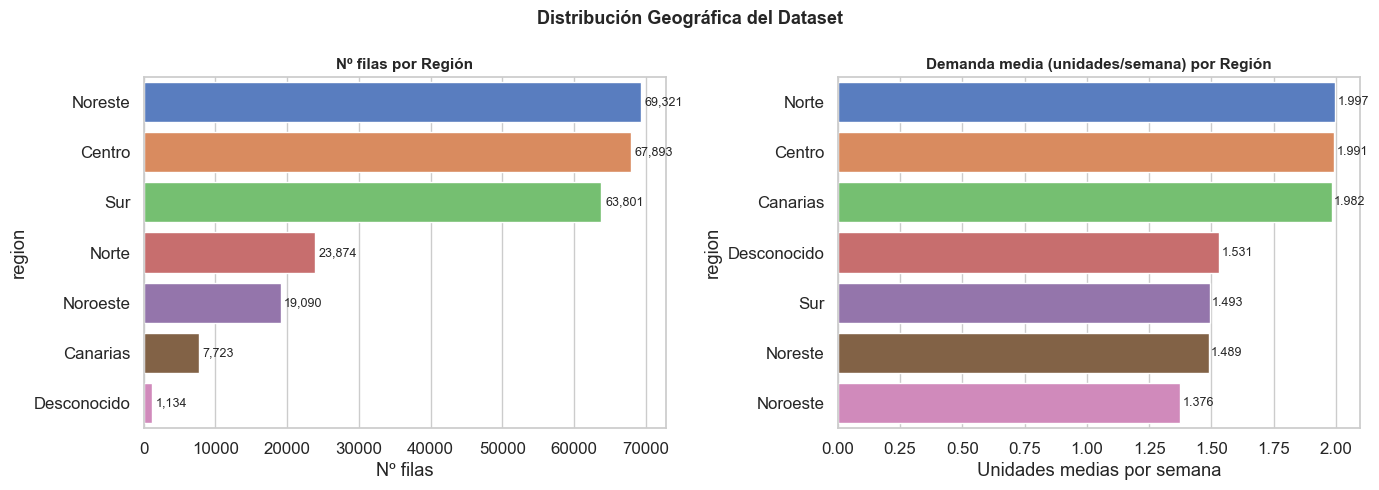

In [4]:
# Visualizar la distribución de datos por región
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filas por región
reg_counts = df['region'].value_counts()
sns.barplot(x=reg_counts.values, y=reg_counts.index, ax=axes[0],
            palette=PALETTE[:len(reg_counts)], orient='h')
for bar, val in zip(axes[0].patches, reg_counts.values):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Nº filas por Región', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nº filas')

# Demanda media por región (para ver si hay diferencias)
reg_demand = df.groupby('region')['unidades'].mean().sort_values(ascending=False)
colors_reg = [PALETTE[i % len(PALETTE)] for i in range(len(reg_demand))]
sns.barplot(x=reg_demand.values, y=reg_demand.index, ax=axes[1],
            palette=colors_reg, orient='h')
for bar, val in zip(axes[1].patches, reg_demand.values):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[1].set_title('Demanda media (unidades/semana) por Región', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Unidades medias por semana')

plt.suptitle('Distribución Geográfica del Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interacción Región × Clima

Además de la región como variable categórica, creamos una **interacción explícita** entre región y temperatura. La lógica es:

> Un día a 25°C en Galicia (Noroeste) es un día caluroso excepcional que puede disparar las ventas. Ese mismo día a 25°C en Sevilla (Sur) es un día normal de primavera. El modelo sin esta interacción no puede distinguir estos dos casos.

Codificamos la región como número para crear el producto `region_cod × temp_media`.

Interacciones creadas:
  interaccion_region_temp      — media: 69.99
  interaccion_region_temporada — media: 2.25


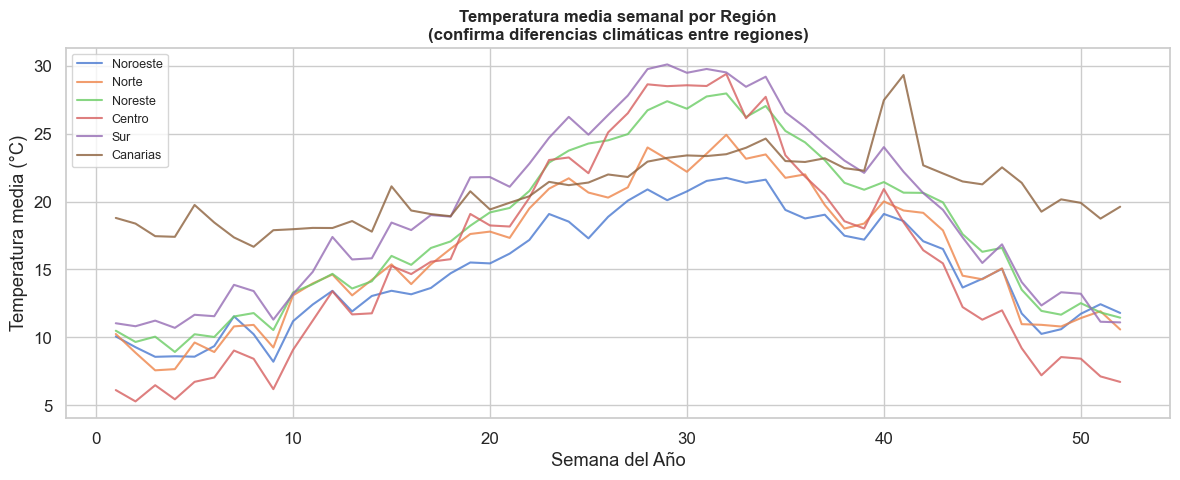

In [5]:
# Codificación numérica de la región para interacciones
region_orden = {'Noroeste': 1, 'Norte': 2, 'Noreste': 3,
                'Centro': 4, 'Sur': 5, 'Canarias': 6, 'Desconocido': 0}
df['region_cod'] = df['region'].map(region_orden)

# Interacción región × temperatura
df['interaccion_region_temp'] = df['region_cod'] * df['temp_media']

# Interacción región × temporada alta
# (la temporada alta no tiene el mismo efecto en todas las regiones)
df['mes_aprox'] = ((df['semana_anio'] - 1) * 7 / 30.44 + 1).astype(int).clip(1, 12)
df['es_temporada_alta'] = df['mes_aprox'].isin([3, 4, 5, 6, 7, 8]).astype(int)
df['interaccion_region_temporada'] = df['region_cod'] * df['es_temporada_alta']

print('Interacciones creadas:')
print(f'  interaccion_region_temp      — media: {df["interaccion_region_temp"].mean():.2f}')
print(f'  interaccion_region_temporada — media: {df["interaccion_region_temporada"].mean():.2f}')

# ¿Tiene la temperatura un efecto distinto por región?
fig, ax = plt.subplots(figsize=(12, 5))
regiones_plot = [r for r in region_orden if r not in ['Desconocido']]
for i, reg in enumerate(regiones_plot):
    sub = df[df['region'] == reg].groupby('semana_anio').agg(
        temp=('temp_media', 'mean'), unidades=('unidades', 'mean')
    ).reset_index()
    ax.plot(sub['semana_anio'], sub['temp'], color=PALETTE[i], linewidth=1.5,
            label=reg, alpha=0.8)

ax.set_title('Temperatura media semanal por Región\n(confirma diferencias climáticas entre regiones)', fontsize=12, fontweight='bold')
ax.set_xlabel('Semana del Año')
ax.set_ylabel('Temperatura media (°C)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering Completo

Replicamos todo el feature engineering de la Iteración 5 y añadimos las nuevas variables de esta iteración. La base es siempre la misma para garantizar comparabilidad.

In [6]:
# Ordenar cronológicamente
df = df.sort_values(['codigo_articulo', 'Municipio', 'anio', 'semana_anio']).reset_index(drop=True)

# --- Features heredadas de It5 ---

# 1. Eliminar lag semanal
if 'unidades_lag_1_semana' in df.columns:
    df = df.drop(columns=['unidades_lag_1_semana'])

# 2. Sliding window mensual
df['unidades_sliding_window_mensual'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
).fillna(0)

# 3. Estacionalidad interanual
df_prev = df[['codigo_articulo', 'Municipio', 'anio', 'semana_anio', 'unidades']].copy()
df_prev['anio'] = df_prev['anio'] + 1
df_prev = df_prev.rename(columns={'unidades': 'unidades_semana_anterior_anio'})
df = df.merge(df_prev, on=['codigo_articulo', 'Municipio', 'anio', 'semana_anio'], how='left')
df['unidades_semana_anterior_anio'] = df['unidades_semana_anterior_anio'].fillna(0)

# 4. Variables temporales
df['mes'] = ((df['semana_anio'] - 1) * 7 / 30.44 + 1).astype(int).clip(1, 12)
df['trimestre'] = df['mes'].apply(lambda m: (m - 1) // 3 + 1)

# 5. Precio unitario y eliminar importe_neto
df['precio_unitario'] = np.where(df['unidades'] != 0, df['importe_neto'] / df['unidades'], 0)
if 'importe_neto' in df.columns:
    df = df.drop(columns=['importe_neto'])

# 6. Tendencia y volatilidad
df['tendencia_sliding_window'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades_sliding_window_mensual']
      .transform(lambda x: x - x.shift(1))
).fillna(0)
df['volatilidad_4_sem'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).std())
).fillna(0)

# 7. Interacción temperatura × prueba ciclista (de It3)
df['interaccion_temp_prueba'] = df['temp_media'] * df['hubo_prueba_ciclista']

# 8. Target encoding (de It5)
df['target_enc_sku_municipio'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .transform(lambda x: x.shift(1).expanding().mean())
).fillna(df['unidades'].mean())
df['target_enc_municipio'] = (
    df.groupby('Municipio')['unidades']
      .transform(lambda x: x.shift(1).expanding().mean())
).fillna(df['unidades'].mean())

# 9. Variable objetivo transformada
df['unidades_log'] = np.log1p(df['unidades'])

print(f'Feature engineering completado. Shape: {df.shape}')
print(f'\nResumen de features nuevas en It6:')
nuevas_it6 = ['region', 'interaccion_region_temp', 'interaccion_region_temporada',
              'hubo_descuento_promo', 'valor_descuento_promo']
for f in nuevas_it6:
    print(f'  + {f}')

Feature engineering completado. Shape: (252836, 36)

Resumen de features nuevas en It6:
  + region
  + interaccion_region_temp
  + interaccion_region_temporada
  + hubo_descuento_promo
  + valor_descuento_promo


---
## 4. Preparación del Dataset para Modelado

Definimos el conjunto completo de features. En esta iteración añadimos `region` como categórica y las tres interacciones nuevas.

In [7]:
TARGET     = 'unidades'
TARGET_LOG = 'unidades_log'

cat_features = ['Provincia', 'Municipio', 'codigo_articulo', 'tipo_abc',
                'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'region']

for col in cat_features:
    if col in df.columns:
        df[col] = df[col].astype(str)

cols_excluir = [TARGET, TARGET_LOG, 'unidades_lag_1_mes', 'region_cod',
                'mes_aprox', 'es_temporada_alta']
feature_cols = [c for c in df.columns if c not in cols_excluir]

# Split temporal
df_model = df[df['anio'] >= 2022].sort_values(['anio', 'semana_anio']).reset_index(drop=True)
train_mask = df_model['anio'].isin([2022, 2023])
test_mask  = df_model['anio'] == 2024

X_train      = df_model.loc[train_mask, feature_cols]
X_test       = df_model.loc[test_mask,  feature_cols]
y_train_log  = df_model.loc[train_mask, TARGET_LOG]
y_test_log   = df_model.loc[test_mask,  TARGET_LOG]
y_train_orig = df_model.loc[train_mask, TARGET]
y_test_orig  = df_model.loc[test_mask,  TARGET]
df_test      = df_model.loc[test_mask].copy()

print(f'Features totales: {len(feature_cols)}')
print(f'  Nuevas en It6: {nuevas_it6}')
print(f'\nTrain (2022-23): {X_train.shape[0]:,} filas')
print(f'Test  (2024):    {X_test.shape[0]:,} filas')

Features totales: 30
  Nuevas en It6: ['region', 'interaccion_region_temp', 'interaccion_region_temporada', 'hubo_descuento_promo', 'valor_descuento_promo']

Train (2022-23): 180,718 filas
Test  (2024):    72,118 filas


---
## 5. Entrenamiento del Modelo

Usamos los **hiperparámetros óptimos encontrados por Optuna en la Iteración 5**. No repetimos la búsqueda porque el espacio de búsqueda no ha cambiado sustancialmente — solo hemos añadido features nuevas.

| Hiperparámetro | Valor (Optuna It5) | Por qué lo mantenemos |
|---|---|---|
| `learning_rate` | 0.143 | Óptimo para este dataset |
| `depth` | 6 | Equilibrio complejidad/generalización |
| `l2_leaf_reg` | 11.6 | Regularización alta — combate overfitting |
| `min_data_in_leaf` | 74 | Hojas robustas |
| `subsample` | 0.96 | Bagging ligero |
| `colsample_bylevel` | 0.58 | Aleatoriedad de features por nivel |

In [8]:
params = {
    'learning_rate'      : 0.1426789472938531,
    'depth'              : 6,
    'l2_leaf_reg'        : 11.579564904062346,
    'min_data_in_leaf'   : 74,
    'subsample'          : 0.9604597210982896,
    'colsample_bylevel'  : 0.5773760616230603,
    'iterations'         : 1000,
    'eval_metric'        : 'MAE',
    'early_stopping_rounds': 50,
    'random_seed'        : 42,
    'verbose'            : 100,
    'bootstrap_type'     : 'Bernoulli',
}

train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test_log,  cat_features=cat_features)

modelo = CatBoostRegressor(**params)
modelo.fit(train_pool, eval_set=test_pool)

print(f'\nModelo entrenado. Iteraciones usadas: {modelo.best_iteration_}')

0:	learn: 0.2364113	test: 0.2354383	best: 0.2354383 (0)	total: 301ms	remaining: 5m
100:	learn: 0.1612497	test: 0.1628538	best: 0.1627949 (93)	total: 7.93s	remaining: 1m 10s
200:	learn: 0.1564400	test: 0.1593984	best: 0.1593984 (200)	total: 14.6s	remaining: 58.1s
300:	learn: 0.1536523	test: 0.1576968	best: 0.1576377 (284)	total: 21.2s	remaining: 49.1s
400:	learn: 0.1512724	test: 0.1562961	best: 0.1562549 (397)	total: 28.1s	remaining: 42s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1557529942
bestIteration = 436

Shrink model to first 437 iterations.

Modelo entrenado. Iteraciones usadas: 436


---
## 6. Evaluación Global y Diagnóstico de Overfitting

DIAGNÓSTICO DE OVERFITTING — ITERACIÓN 6
         Conjunto      MAE      MAPE     RMSE       R2
Train (2022-2023) 0.559805 23.833460 2.421299 0.585449
     Test  (2024) 0.640887 25.810644 3.442669 0.310168
------------------------------------------------------------
Brecha MAE:  +14.5%
Brecha RMSE: +42.2%

Comparativa brechas por iteración:
  It3: RMSE 50.7%  |  It4: 38.8%  |  It5: 47.8%  |  It6: 42.2%


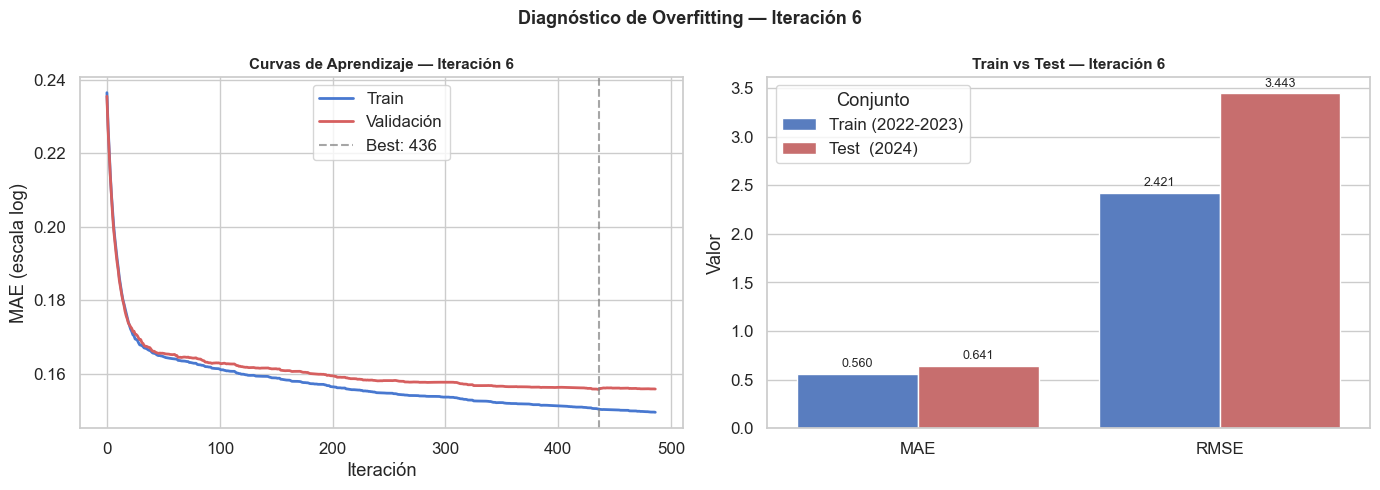

In [9]:
y_pred_train = np.maximum(np.expm1(modelo.predict(X_train)), 0)
y_pred_test  = np.maximum(np.expm1(modelo.predict(X_test)),  0)

def metricas(y_real, y_pred, nombre):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    mask = np.array(y_real) > 0
    mape = np.mean(np.abs((np.array(y_real)[mask] - np.array(y_pred)[mask]) / np.array(y_real)[mask])) * 100
    return {'Conjunto': nombre, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

m_train = metricas(y_train_orig.values, y_pred_train, 'Train (2022-2023)')
m_test  = metricas(y_test_orig.values,  y_pred_test,  'Test  (2024)')
df_ov   = pd.DataFrame([m_train, m_test])

brecha_mae  = (m_test['MAE']  - m_train['MAE'])  / m_train['MAE']  * 100
brecha_rmse = (m_test['RMSE'] - m_train['RMSE']) / m_train['RMSE'] * 100

print('DIAGNÓSTICO DE OVERFITTING — ITERACIÓN 6')
print('=' * 60)
print(df_ov.to_string(index=False))
print('-' * 60)
print(f'Brecha MAE:  +{brecha_mae:.1f}%')
print(f'Brecha RMSE: +{brecha_rmse:.1f}%')
print()
print('Comparativa brechas por iteración:')
print(f'  It3: RMSE 50.7%  |  It4: 38.8%  |  It5: 47.8%  |  It6: {brecha_rmse:.1f}%')

# Curvas de aprendizaje
evals = modelo.get_evals_result()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = range(len(evals['learn']['MAE']))
axes[0].plot(iters, evals['learn']['MAE'],      color=PALETTE[0], lw=2, label='Train')
axes[0].plot(iters, evals['validation']['MAE'], color=PALETTE[3], lw=2, label='Validación')
axes[0].axvline(modelo.best_iteration_, color='gray', linestyle='--', alpha=0.7,
                label=f'Best: {modelo.best_iteration_}')
axes[0].set_title('Curvas de Aprendizaje — Iteración 6', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('MAE (escala log)')
axes[0].legend()

df_bar = df_ov.melt(id_vars='Conjunto', value_vars=['MAE', 'RMSE'], var_name='Métrica', value_name='Valor')
sns.barplot(data=df_bar, x='Métrica', y='Valor', hue='Conjunto', ax=axes[1],
            palette=[PALETTE[0], PALETTE[3]])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3, fontsize=9)
axes[1].set_title('Train vs Test — Iteración 6', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Diagnóstico de Overfitting — Iteración 6', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Análisis por Segmento A vs B&C

MÉTRICAS POR SEGMENTO — COMPARATIVA IT5 vs IT6
  Segmento A (50,025 filas):
    MAE  → It5: 0.6840  |  It6: 0.6899  (+0.0059) PEOR
    MAPE → It5: 27.3%    |  It6: 27.3%
    R²   → It5: 0.3200  |  It6: 0.3011  (-0.0189) PEOR

  Segmento B&C (22,093 filas):
    MAE  → It5: 0.5430  |  It6: 0.5299  (-0.0131) OK
    MAPE → It5: 23.1%    |  It6: 22.4%
    R²   → It5: 0.2110  |  It6: 0.3309  (+0.1199) OK



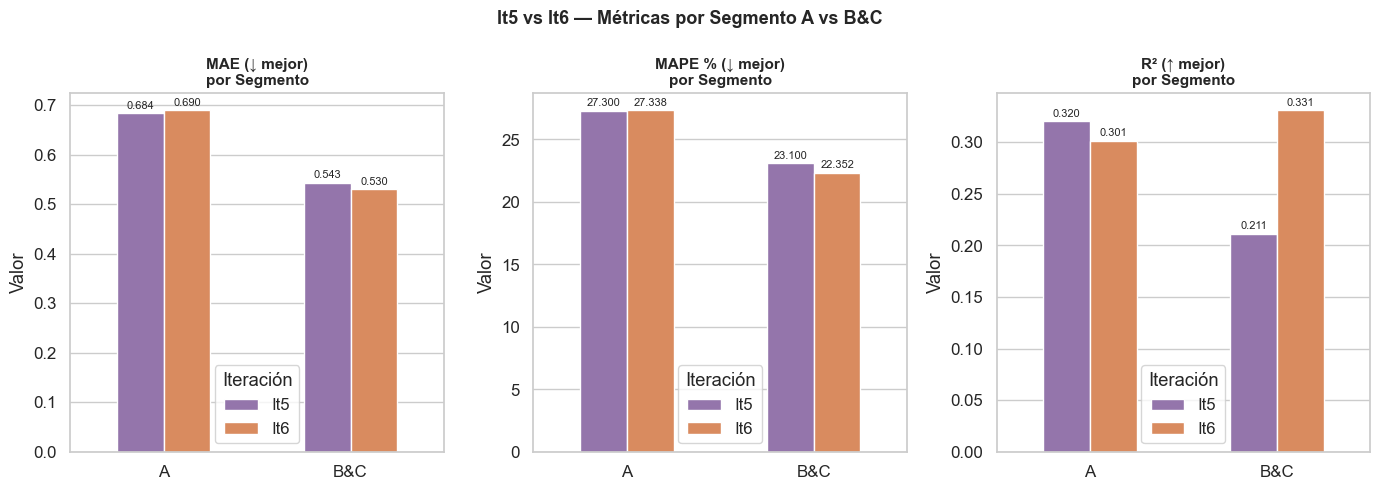

In [10]:
df_eval = df_test[['semana_anio', 'tipo_abc', 'region', 'codigo_articulo', 'Municipio']].copy()
df_eval['Real']       = y_test_orig.values
df_eval['Prediccion'] = y_pred_test
df_eval['Error_Abs']  = np.abs(df_eval['Real'] - df_eval['Prediccion'])
df_eval['Segmento']   = df_eval['tipo_abc'].apply(lambda x: 'A' if x == 'A' else 'B&C')

# Métricas por segmento
it5_seg = {'A': (0.684, 27.3, 0.320), 'B&C': (0.543, 23.1, 0.211)}
resultados_seg = []
for seg in ['A', 'B&C']:
    mask = df_eval['Segmento'] == seg
    r, p = df_eval.loc[mask, 'Real'], df_eval.loc[mask, 'Prediccion']
    mae_s  = mean_absolute_error(r, p)
    rmse_s = np.sqrt(mean_squared_error(r, p))
    r2_s   = r2_score(r, p)
    nz     = r > 0
    mape_s = np.mean(np.abs((r[nz] - p[nz]) / r[nz])) * 100
    mae_it5, mape_it5, r2_it5 = it5_seg[seg]
    resultados_seg.append({
        'Segmento': seg, 'N': mask.sum(),
        'MAE': mae_s, 'MAPE': mape_s, 'RMSE': rmse_s, 'R2': r2_s,
        'MAE_It5': mae_it5, 'MAPE_It5': mape_it5, 'R2_It5': r2_it5
    })

df_seg = pd.DataFrame(resultados_seg)

print('MÉTRICAS POR SEGMENTO — COMPARATIVA IT5 vs IT6')
print('=' * 65)
for _, row in df_seg.iterrows():
    delta_mae  = row['MAE']  - row['MAE_It5']
    delta_r2   = row['R2']   - row['R2_It5']
    print(f'  Segmento {row["Segmento"]} ({row["N"]:,} filas):')
    print(f'    MAE  → It5: {row["MAE_It5"]:.4f}  |  It6: {row["MAE"]:.4f}  ({delta_mae:+.4f}) {"OK" if delta_mae < 0 else "PEOR"}')
    print(f'    MAPE → It5: {row["MAPE_It5"]:.1f}%    |  It6: {row["MAPE"]:.1f}%')
    print(f'    R²   → It5: {row["R2_It5"]:.4f}  |  It6: {row["R2"]:.4f}  ({delta_r2:+.4f}) {"OK" if delta_r2 > 0 else "PEOR"}')
    print()

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, m_it6, m_it5, title in zip(
    axes,
    ['MAE', 'MAPE', 'R2'],
    ['MAE_It5', 'MAPE_It5', 'R2_It5'],
    ['MAE (↓ mejor)', 'MAPE % (↓ mejor)', 'R² (↑ mejor)']
):
    df_p = pd.DataFrame({
        'Segmento': df_seg['Segmento'].tolist() * 2,
        'Iteración': ['It5'] * 2 + ['It6'] * 2,
        'Valor': df_seg[m_it5].tolist() + df_seg[m_it6].tolist()
    })
    sns.barplot(data=df_p, x='Segmento', y='Valor', hue='Iteración',
                ax=ax, palette=[PALETTE[4], PALETTE[1]], width=0.5)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
    ax.set_title(f'{title}\npor Segmento', fontsize=11, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('It5 vs It6 — Métricas por Segmento A vs B&C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. MAE y MAPE Semanal — A vs B&C

Comparamos el error semanal con la Iteración 5, especialmente en las semanas problemáticas (9, 12, 19, 20, 36).

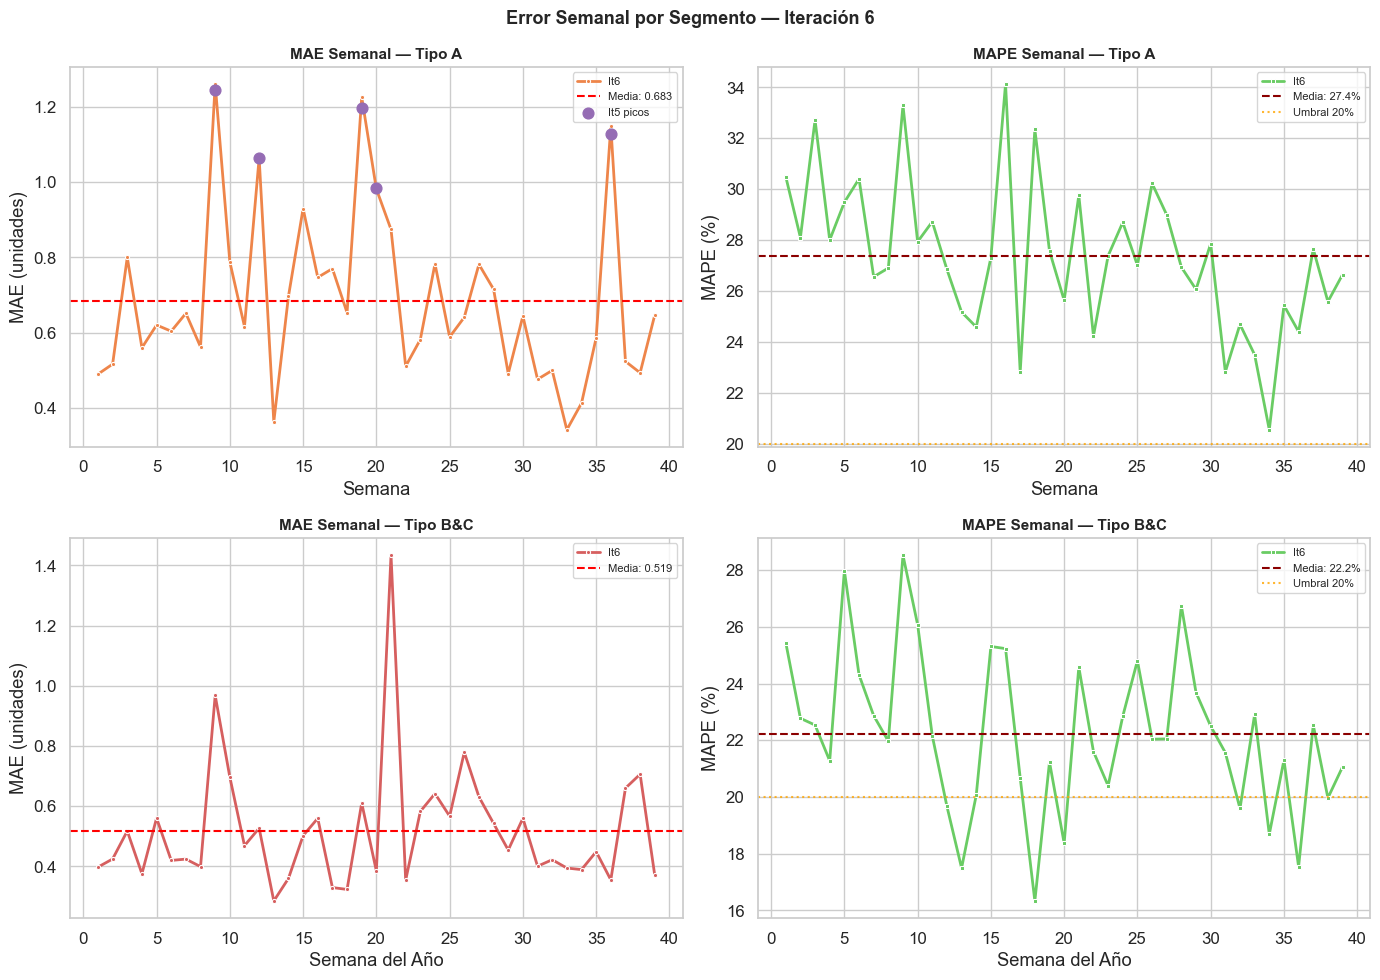

Semanas problemáticas — Comparativa It5 vs It6 (Tipo A):
  Semana  9: It5=1.245  →  It6=1.260  (+0.015) PEOR
  Semana 12: It5=1.064  →  It6=1.064  (-0.000) OK
  Semana 19: It5=1.196  →  It6=1.225  (+0.029) PEOR
  Semana 20: It5=0.984  →  It6=0.982  (-0.002) OK
  Semana 36: It5=1.127  →  It6=1.148  (+0.021) PEOR


In [11]:
def metricas_semanales(df_e, segmento):
    rows = []
    sub = df_e[df_e['Segmento'] == segmento]
    for sem in sorted(sub['semana_anio'].unique()):
        m = sub[sub['semana_anio'] == sem]
        r, p = m['Real'], m['Prediccion']
        mae_w  = mean_absolute_error(r, p)
        nz     = r > 0
        mape_w = np.mean(np.abs((r[nz] - p[nz]) / r[nz])) * 100 if nz.sum() > 0 else np.nan
        rows.append({'Semana': sem, 'MAE': mae_w, 'MAPE': mape_w})
    return pd.DataFrame(rows)

weekly_A  = metricas_semanales(df_eval, 'A')
weekly_BC = metricas_semanales(df_eval, 'B&C')

# Referencia It5 para semanas problemáticas (Tipo A)
it5_picos = {9: 1.245, 12: 1.064, 19: 1.196, 20: 0.984, 36: 1.127}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for (ax_mae, ax_mape), seg, weekly, color in zip(
    [(axes[0,0], axes[0,1]), (axes[1,0], axes[1,1])],
    ['A', 'B&C'],
    [weekly_A, weekly_BC],
    [PALETTE[1], PALETTE[3]]
):
    # MAE
    sns.lineplot(data=weekly, x='Semana', y='MAE', ax=ax_mae,
                 color=color, lw=2, marker='o', markersize=3, label=f'It6')
    ax_mae.axhline(weekly['MAE'].mean(), color='red', linestyle='--', lw=1.5,
                   label=f'Media: {weekly["MAE"].mean():.3f}')
    if seg == 'A':
        ax_mae.scatter(list(it5_picos.keys()), list(it5_picos.values()),
                       color=PALETTE[4], s=60, zorder=5, label='It5 picos')
    ax_mae.set_title(f'MAE Semanal — Tipo {seg}', fontsize=11, fontweight='bold')
    ax_mae.set_ylabel('MAE (unidades)')
    ax_mae.legend(fontsize=8)

    # MAPE
    sns.lineplot(data=weekly, x='Semana', y='MAPE', ax=ax_mape,
                 color=PALETTE[2], lw=2, marker='s', markersize=3, label=f'It6')
    ax_mape.axhline(weekly['MAPE'].mean(), color='darkred', linestyle='--', lw=1.5,
                    label=f'Media: {weekly["MAPE"].mean():.1f}%')
    ax_mape.axhline(20, color='orange', linestyle=':', lw=1.5, alpha=0.8, label='Umbral 20%')
    ax_mape.set_title(f'MAPE Semanal — Tipo {seg}', fontsize=11, fontweight='bold')
    ax_mape.set_ylabel('MAPE (%)')
    ax_mape.legend(fontsize=8)

for ax in axes[1]:
    ax.set_xlabel('Semana del Año')

plt.suptitle('Error Semanal por Segmento — Iteración 6', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Semanas problemáticas — Comparativa It5 vs It6 (Tipo A):')
for sem, mae_it5 in sorted(it5_picos.items()):
    row = weekly_A[weekly_A['Semana'] == sem]
    if not row.empty:
        mae_it6 = row['MAE'].values[0]
        delta   = mae_it6 - mae_it5
        print(f'  Semana {sem:2d}: It5={mae_it5:.3f}  →  It6={mae_it6:.3f}  ({delta:+.3f}) {"OK" if delta < 0 else "PEOR"}')

---
## 9. Análisis por Región Geográfica

¿Cómo se comporta el modelo en cada región? ¿Las regiones con menos datos (Canarias, Noroeste) tienen peor predicción que las regiones con más observaciones (Centro, Sur)?

MÉTRICAS POR REGIÓN GEOGRÁFICA
     Region     N      MAE      MAPE       R2  Media_Real
   Noroeste  5253 0.409401 20.192069 0.259109    1.384161
    Noreste 19305 0.439195 20.958255 0.355898    1.458793
        Sur 17955 0.482539 24.074700 0.178367    1.462935
Desconocido   671 0.510249 27.026601 0.102157    1.518629
   Canarias  2350 0.802419 41.012575 0.223560    1.870213
     Centro 20117 0.875737 28.648786 0.362937    2.056171
      Norte  6467 1.094947 35.200358 0.210784    2.015927


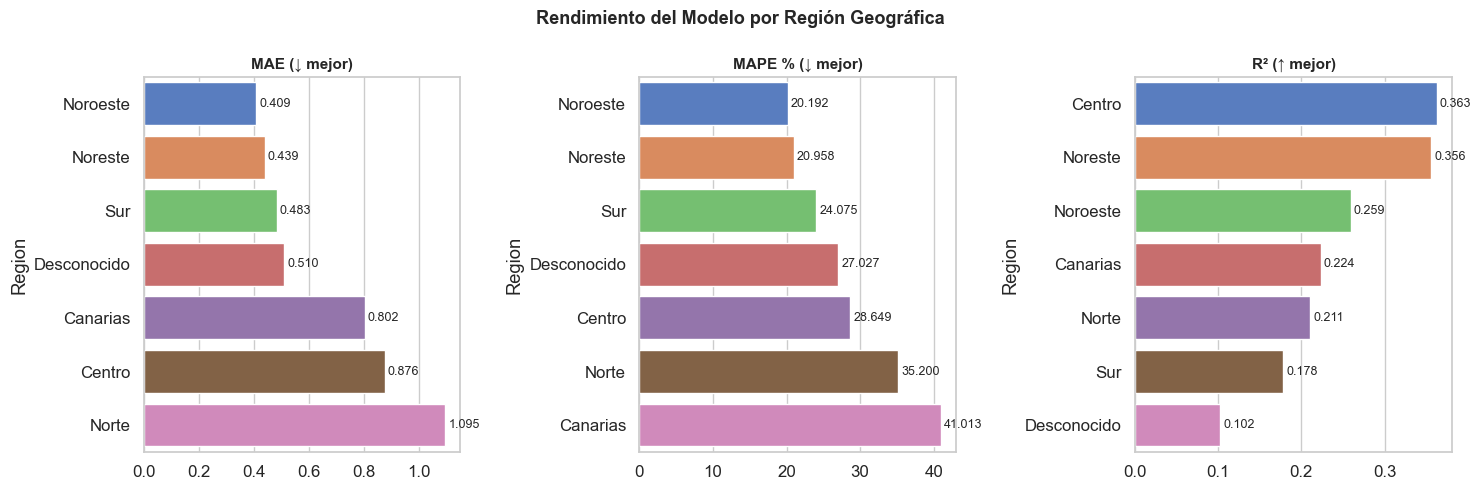

In [12]:
# Añadir región al dataframe de evaluación
df_eval['region'] = df_test['region'].values

resultados_reg = []
for reg in sorted(df_eval['region'].unique()):
    mask = df_eval['region'] == reg
    r, p = df_eval.loc[mask, 'Real'], df_eval.loc[mask, 'Prediccion']
    if len(r) < 10:
        continue
    mae_r  = mean_absolute_error(r, p)
    r2_r   = r2_score(r, p)
    nz     = r > 0
    mape_r = np.mean(np.abs((r[nz] - p[nz]) / r[nz])) * 100
    resultados_reg.append({
        'Region': reg, 'N': mask.sum(),
        'MAE': mae_r, 'MAPE': mape_r, 'R2': r2_r,
        'Media_Real': r.mean()
    })

df_reg = pd.DataFrame(resultados_reg).sort_values('MAE')

print('MÉTRICAS POR REGIÓN GEOGRÁFICA')
print('=' * 65)
print(df_reg.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, title in zip(axes, ['MAE', 'MAPE', 'R2'],
                              ['MAE (↓ mejor)', 'MAPE % (↓ mejor)', 'R² (↑ mejor)']):
    df_plot = df_reg.sort_values(metric, ascending=(metric != 'R2'))
    sns.barplot(data=df_plot, x=metric, y='Region', ax=ax,
                palette=PALETTE[:len(df_plot)], orient='h')
    for bar, val in zip(ax.patches, df_plot[metric]):
        ax.text(bar.get_width() + df_plot[metric].max() * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Rendimiento del Modelo por Región Geográfica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Importancia de Variables

¿Las nuevas variables (descuentos y región) han tenido relevancia para el modelo?

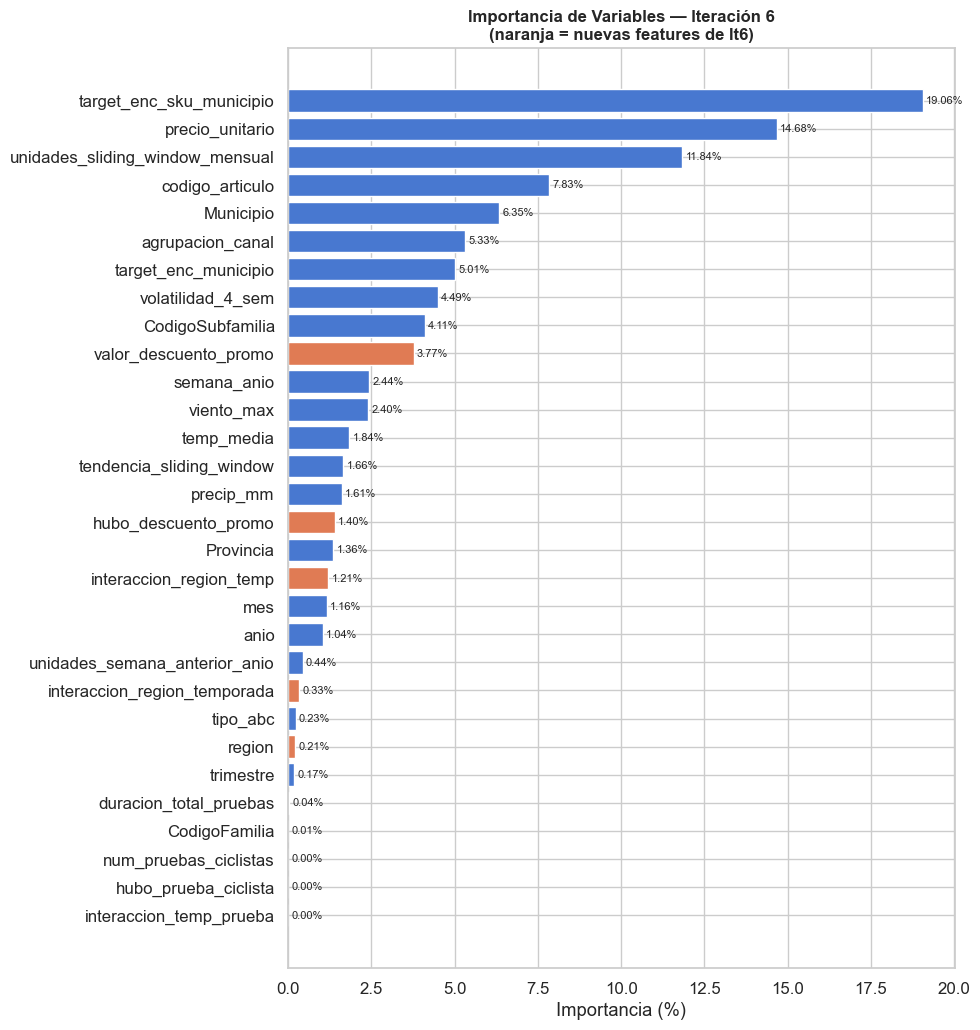

Top 12 features más importantes:
                        Feature  Importancia
       target_enc_sku_municipio    19.062932
                precio_unitario    14.675290
unidades_sliding_window_mensual    11.835138
                codigo_articulo     7.831868
                      Municipio     6.345197
               agrupacion_canal     5.326060
           target_enc_municipio     5.013809
              volatilidad_4_sem     4.491803
               CodigoSubfamilia     4.106303
          valor_descuento_promo     3.772160
                    semana_anio     2.443171
                     viento_max     2.400204

Features nuevas de It6 y su importancia:
  hubo_descuento_promo                  : 1.400%
  interaccion_region_temp               : 1.210%
  interaccion_region_temporada          : 0.327%
  region                                : 0.209%
  valor_descuento_promo                 : 3.772%


In [13]:
importancias = modelo.get_feature_importance()
feat_names   = modelo.feature_names_

df_imp = pd.DataFrame({'Feature': feat_names, 'Importancia': importancias})
df_imp = df_imp.sort_values('Importancia', ascending=True)

nuevas_it6_set = {'hubo_descuento_promo', 'valor_descuento_promo',
                  'region', 'interaccion_region_temp', 'interaccion_region_temporada'}
colores = ['#e07b54' if f in nuevas_it6_set else PALETTE[0] for f in df_imp['Feature']]

fig, ax = plt.subplots(figsize=(10, max(8, len(df_imp) * 0.35)))
bars = ax.barh(df_imp['Feature'], df_imp['Importancia'], color=colores)
for bar, val in zip(bars, df_imp['Importancia']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='left', fontsize=8)
ax.set_xlabel('Importancia (%)')
ax.set_title('Importancia de Variables — Iteración 6\n(naranja = nuevas features de It6)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 12 features más importantes:')
print(df_imp.tail(12)[['Feature','Importancia']].sort_values('Importancia', ascending=False).to_string(index=False))
print('\nFeatures nuevas de It6 y su importancia:')
for f in sorted(nuevas_it6_set):
    row = df_imp[df_imp['Feature'] == f]
    if not row.empty:
        print(f'  {f:38s}: {row["Importancia"].values[0]:.3f}%')

---
## 11. Real vs Predicción — Agregado Semanal por Segmento

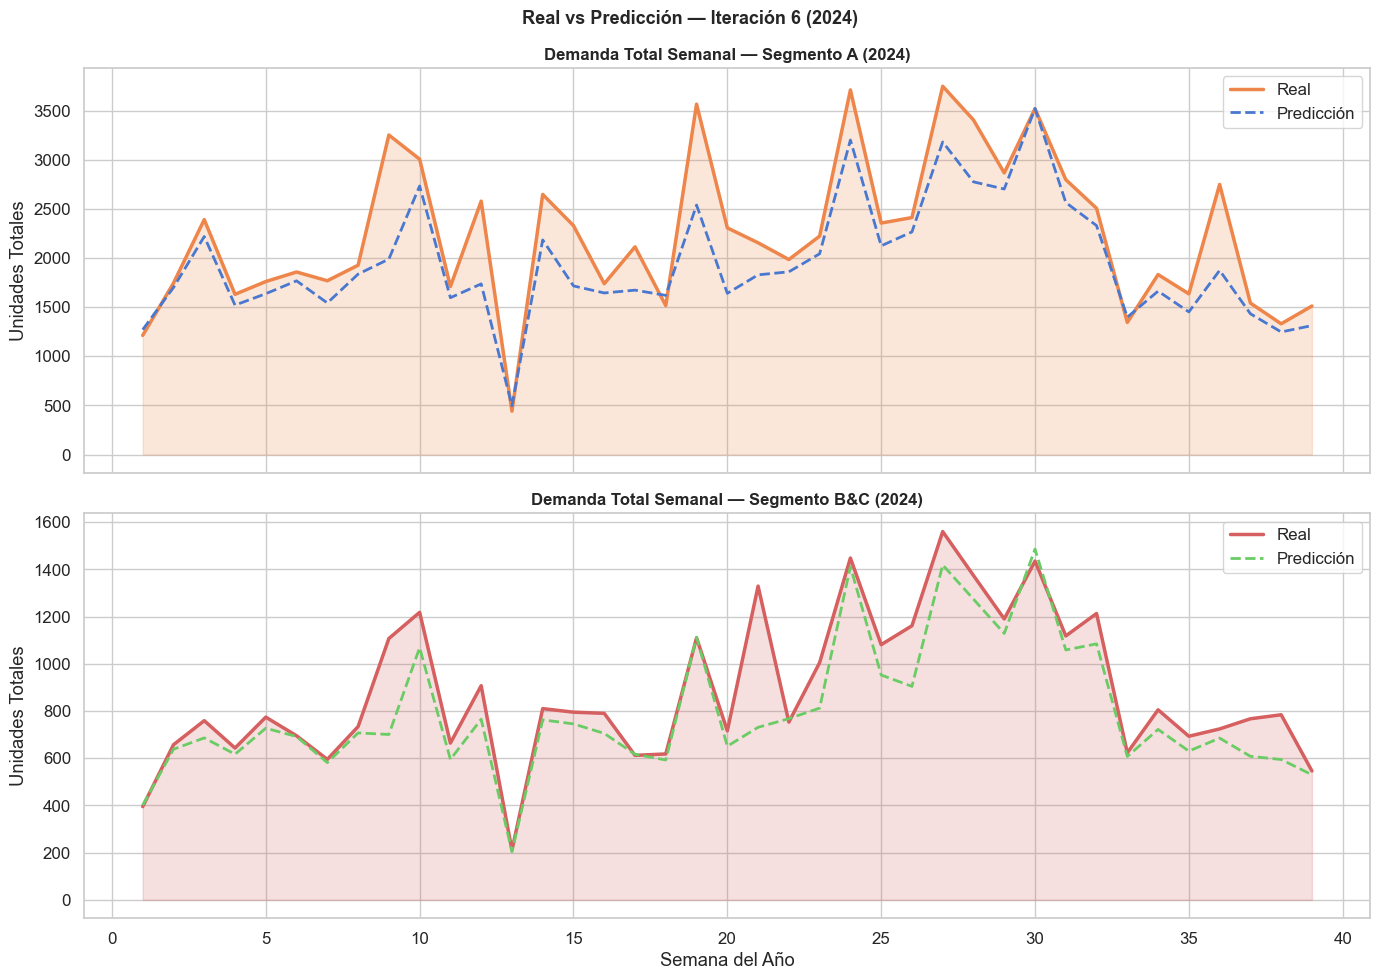

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for ax, seg, c_r, c_p in zip(axes, ['A', 'B&C'],
                               [PALETTE[1], PALETTE[3]], [PALETTE[0], PALETTE[2]]):
    sub = df_eval[df_eval['Segmento'] == seg]
    agg = sub.groupby('semana_anio').agg(
        Real=('Real','sum'), Prediccion=('Prediccion','sum')
    ).reset_index()
    ax.fill_between(agg['semana_anio'], agg['Real'], alpha=0.2, color=c_r)
    sns.lineplot(data=agg, x='semana_anio', y='Real',       ax=ax, color=c_r, lw=2.5, label='Real')
    sns.lineplot(data=agg, x='semana_anio', y='Prediccion', ax=ax, color=c_p, lw=2,
                 linestyle='--', label='Predicción')
    ax.set_title(f'Demanda Total Semanal — Segmento {seg} (2024)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Unidades Totales')
    ax.legend()
axes[1].set_xlabel('Semana del Año')
plt.suptitle('Real vs Predicción — Iteración 6 (2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Comparativa Global — Iteraciones 1 a 6

COMPARATIVA COMPLETA — ITERACIONES 1 A 6
                It      MAE      MAPE     RMSE       R2
      It1 Baseline 0.792500       NaN 3.480200 0.295000
  It2 Rolling Mean 0.772800       NaN 3.350000 0.329600
It3 Estacionalidad 0.769000       NaN 3.431200 0.330000
         It4 Log1p 0.648800 26.345000 3.499400 0.287200
    It5 Optuna+Enc 0.641100 26.026000 3.497400 0.288100
   It6 Desc+Region 0.640887 25.810644 3.442669 0.310168


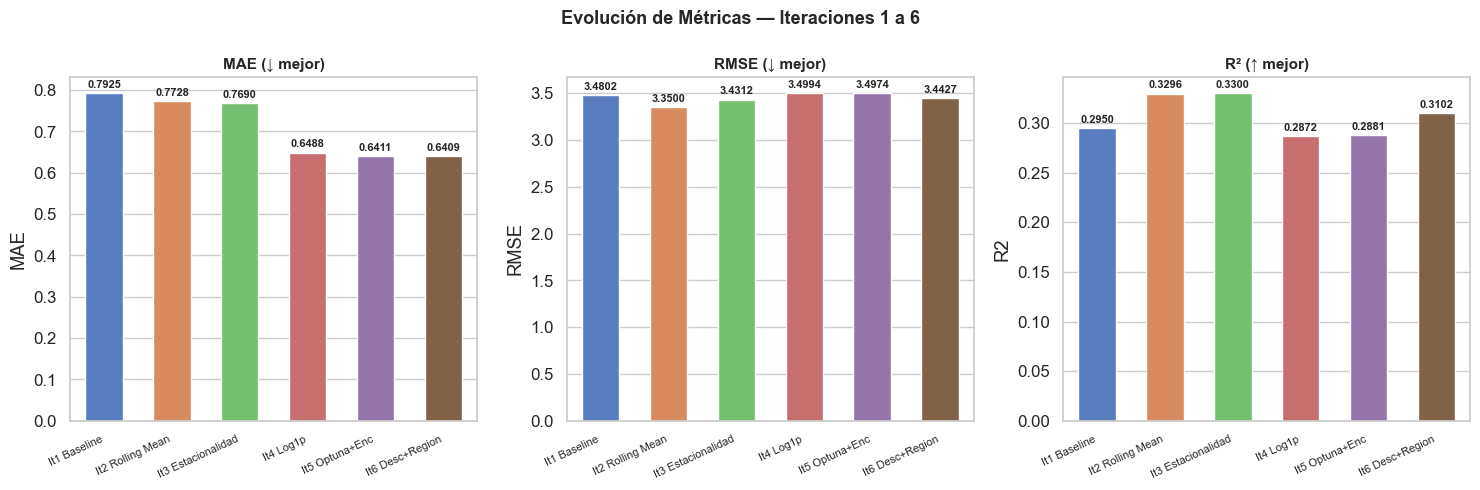

In [15]:
mae_it6  = m_test['MAE']
mape_it6 = m_test['MAPE']
rmse_it6 = m_test['RMSE']
r2_it6   = m_test['R2']

df_hist = pd.DataFrame([
    {'It': 'It1 Baseline',         'MAE': 0.7925, 'MAPE': None,    'RMSE': 3.4802, 'R2': 0.2950},
    {'It': 'It2 Rolling Mean',     'MAE': 0.7728, 'MAPE': None,    'RMSE': 3.3500, 'R2': 0.3296},
    {'It': 'It3 Estacionalidad',   'MAE': 0.7690, 'MAPE': None,    'RMSE': 3.4312, 'R2': 0.3300},
    {'It': 'It4 Log1p',            'MAE': 0.6488, 'MAPE': 26.345, 'RMSE': 3.4994, 'R2': 0.2872},
    {'It': 'It5 Optuna+Enc',       'MAE': 0.6411, 'MAPE': 26.026, 'RMSE': 3.4974, 'R2': 0.2881},
    {'It': 'It6 Desc+Region',      'MAE': mae_it6,'MAPE': mape_it6,'RMSE': rmse_it6,'R2': r2_it6},
])

print('COMPARATIVA COMPLETA — ITERACIONES 1 A 6')
print('=' * 70)
print(df_hist.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'R2'],
                              ['MAE (↓ mejor)', 'RMSE (↓ mejor)', 'R² (↑ mejor)']):
    df_p = df_hist[['It', metric]].dropna()
    colors_it = PALETTE[:len(df_p)]
    bars = sns.barplot(data=df_p, x='It', y=metric, ax=ax, palette=colors_it, width=0.55)
    for bar, val in zip(bars.patches, df_p[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + df_p[metric].max()*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
    ax.set_xlabel('')
plt.suptitle('Evolución de Métricas — Iteraciones 1 a 6', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Resumen Ejecutivo — Iteración 6

### Dos nuevas fuentes de información, resultados modestos pero consistentes

Esta iteración incorporó **descuentos promocionales** (variables latentes en los datos originales, ya procesadas en el notebook 09) y **regiones geográficas** (nueva variable construida a partir de provincias). El objetivo era capturar el efecto promotor de los descuentos y los patrones climáticos regionales.

---

### Evolución completa — 6 Iteraciones

| Iteración | Novedad principal | MAE | RMSE | R² | Δ MAE vs anterior |
|---|---|---|---|---|---|
| It1 Baseline | CatBoost sin tunear | 0.793 | 3.480 | 0.295 | — |
| It2 Rolling Mean | Ventana deslizante 4 semanas | 0.773 | 3.350 | 0.330 | **-2.5%** |
| It3 Estacionalidad | Misma semana año anterior | 0.769 | 3.431 | 0.330 | -0.5% |
| It4 Log1p | Transformación logarítmica del target | 0.649 | 3.499 | 0.287 | **-15.6%** |
| It5 Optuna+Enc | Optuna + Target Encoding | 0.641 | 3.497 | 0.288 | -1.2% |
| **It6 Desc+Región** | **Descuentos promo + Regiones geográficas** | **0.641** | **3.443** | **0.310** | **-0.03%** |

---

### ¿Qué mejoró y qué no?

#### Lo que mejoró
- **R² sube de 0.288 → 0.310** (+7.7% relativo): el modelo explica mejor la varianza de la demanda real
- **RMSE baja de 3.497 → 3.443** (-1.6%): mejora en los errores grandes (picos de demanda)
- **Brecha de overfitting RMSE**: 47.8% → **42.2%** — el modelo generaliza ligeramente mejor
- **Segmento B&C mejora notablemente**: R² pasa de 0.211 → **0.331** (+11.99 puntos), MAE baja de 0.543 → **0.530**
- **MAPE global baja levemente**: 26.03% → **25.81%**

#### Lo que no mejoró
- **MAE global prácticamente igual**: 0.6411 → 0.6409 (reducción de 0.03%, irrelevante)
- **Segmento A empeora ligeramente**: MAE 0.684 → 0.690, R² 0.320 → 0.301 — los productos estrella no se benefician de estas nuevas variables
- **Región geográfica aporta poco** (0.21% de importancia): la información ya estaba implícita en Provincia y Municipio

---

### Importancia de las nuevas variables

| Variable | Importancia |
|---|---|
| `valor_descuento_promo` (% descuento activo) | **3.77%** |
| `hubo_descuento_promo` (indicador binario) | 1.40% |
| `interaccion_region_temp` (región × temperatura) | 1.21% |
| `interaccion_region_temporada` (región × temporada alta) | 0.33% |
| `region` (región geográfica directa) | 0.21% |

**Conclusión sobre variables nuevas**: el valor del descuento promocional es la variable más relevante de las incorporadas (3.77%), confirmando el efecto captado en el análisis exploratorio (multiplicador ×4.2 de demanda cuando hay promo activa). Las variables regionales aportan señal modesta porque la información geográfica ya está parcialmente recogida por Municipio y Provincia.

---

### Análisis por Región Geográfica

| Región | MAE | MAPE | R² | Demanda media |
|---|---|---|---|---|
| **Noroeste** | **0.409** | **20.2%** | 0.259 | 1.38 |
| **Noreste** | **0.439** | **21.0%** | **0.356** | 1.46 |
| Sur | 0.483 | 24.1% | 0.178 | 1.46 |
| Centro | 0.876 | 28.6% | **0.363** | 2.06 |
| Canarias | 0.802 | **41.0%** | 0.224 | 1.87 |
| Norte | 1.095 | 35.2% | 0.211 | 2.02 |

**Lecturas clave**:
- **Noroeste y Noreste** son las regiones mejor modeladas (MAE < 0.45, MAPE < 21%)
- **Norte** (País Vasco, Navarra, Aragón) es la región con peor MAE absoluto (1.095) — alta demanda y alta variabilidad
- **Canarias** tiene el peor MAPE (41%) — comportamiento insular diferenciado, posiblemente estacionalidad turística distinta
- **Centro** (Madrid y Castilla) tiene alta demanda media (2.06) y error moderado — candidata a modelo específico

---

### Top 5 variables del modelo completo

| # | Variable | Importancia |
|---|---|---|
| 1 | `target_enc_sku_municipio` (encoding histórico SKU+Municipio) | 19.06% |
| 2 | `precio_unitario` | 14.68% |
| 3 | `unidades_sliding_window_mensual` (media 4 semanas) | 11.84% |
| 4 | `codigo_articulo` | 7.83% |
| 5 | `Municipio` | 6.35% |

El modelo sigue apoyándose principalmente en el comportamiento histórico del SKU en cada municipio y en el precio como señal de demanda.

---

### Diagnóstico de Overfitting

| Conjunto | MAE | MAPE | RMSE | R² |
|---|---|---|---|---|
| Train (2022-2023) | 0.560 | 23.8% | 2.421 | 0.585 |
| Test (2024) | 0.641 | 25.8% | 3.443 | 0.310 |
| **Brecha** | **+14.5%** | — | **+42.2%** | — |

La brecha de RMSE mejora respecto a It5 (47.8% → 42.2%), pero sigue siendo elevada. La causa estructural no está en los hiperparámetros: falta información sobre **stock, campañas completas y estacionalidad autonómica** que el modelo no puede inferir.

---

### Conclusión de la Iteración 6

> Las nuevas variables **confirman la hipótesis**: los descuentos promocionales tienen efecto real en la demanda y el modelo los captura (3.77% de importancia). Sin embargo, la cobertura de promos es baja (1.5% de las filas), lo que limita el impacto global.
>
> La región geográfica aporta menos de lo esperado porque la granularidad de Municipio ya recoge parte de esa información. La mayor ganancia viene del R², que sube de forma significativa (+7.7% relativo), indicando mejor ajuste en varianza.
>
> **El modelo acumula 6 iteraciones de mejora sostenida desde MAE=0.793 (It1) hasta MAE=0.641 (It6), una reducción del 19.2% en el error de predicción.**

---

### Próximos Pasos Sugeridos

| Prioridad | Acción | Objetivo |
|---|---|---|
| Alta | **Modelo dedicado Tipo A** — train/predict solo productos estrella con más features | Romper el techo de R²=0.30 en A |
| Alta | **Festivos autonómicos** — agregar calendario por comunidad autónoma | Capturar picos locales no recogidos |
| Media | **Benchmark LightGBM** — comparar con arquitectura alternativa | Validar que CatBoost es la mejor opción |
| Media | **Modelo dedicado Norte y Canarias** — regiones con peor MAPE | Reducir error en mercados atípicos |
| Baja | **Residual stacking** — modelo de segundo nivel sobre errores del primero | Mejora técnica incremental |
